Name: Boga Petruska and Bence Szabo\
Class: ECBS5171 - Data Analysis 3\
Assignment: Assignment 2 - Fast Growth Prediction\
Date: Feb 15, 2026

Modeling Notebook

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix, 
    brier_score_loss, mean_squared_error
)

sns.set_theme(style="whitegrid")
random_seed = 42

sns.set_theme(style="whitegrid")
random_seed = 42

## Task 1

### PART I: Probability prediction

In [2]:
# load prepped data

csv_path = "../data/prepped/bisnode_firms_prepped.csv"
data = pd.read_csv(csv_path)

print(f"Loaded: {data.shape[0]:,} rows, {data.shape[1]} columns")
print(f"Fast-growth rate: {data['fast_growth'].mean():.1%}")

Loaded: 15,220 rows, 89 columns
Fast-growth rate: 28.8%


In [3]:
# interaction terms
interactions = [
    ("ind2_cat", "age"), ("ind2_cat", "age2"),
    ("ind2_cat", "sales_mil_log"), ("ind2_cat", "ceo_age"),
    ("ind2_cat", "foreign_management"),
    ("sales_mil_log", "age"), ("sales_mil_log", "profit_loss_year_pl"),
    ("sales_mil_log", "foreign_management"),
]

for var1, var2 in interactions:
    col_name = f"{var1}*{var2}"
    data[col_name] = data[var1] * data[var2]

print(f"Interaction terms created: {len(interactions)}")

Interaction terms created: 8


In [4]:
# organize variable lists for modeling
rawvars = ["curr_assets", "curr_liab", "extra_exp", "extra_inc", 
           "extra_profit_loss", "fixed_assets", "inc_bef_tax", 
           "intang_assets", "inventories", "liq_assets", "material_exp",
           "personnel_exp", "profit_loss_year", "sales", "share_eq", 
           "subscribed_cap"]

qualityvars = ["balsheet_flag", "balsheet_length", "balsheet_notfullyear"]

engvar = ["total_assets_bs", "fixed_assets_bs", "liq_assets_bs", 
          "curr_assets_bs", "share_eq_bs", "subscribed_cap_bs",
          "intang_assets_bs", "extra_exp_pl", "extra_inc_pl",
          "extra_profit_loss_pl", "inc_bef_tax_pl", "inventories_pl",
          "material_exp_pl", "profit_loss_year_pl", "personnel_exp_pl"]

engvar2 = ["extra_profit_loss_pl_quad", "inc_bef_tax_pl_quad",
           "profit_loss_year_pl_quad", "share_eq_bs_quad"]

# Collect all flag variables dynamically
engvar3 = [col for col in data.columns 
           if col.endswith(("flag_low", "flag_high", "flag_zero"))]

hr = ["female", "ceo_age", "flag_high_ceo_age", "flag_low_ceo_age",
      "flag_miss_ceo_age", "ceo_count", "foreign_management"]

firm = ["age", "age2", "new", "ind2_cat", "manufacturing_flg", 
        "services_flg", "urban_m"]

interactions_list = [f"{v1}*{v2}" for v1, v2 in interactions]

print(f"Variable counts:")
print(f"  Raw: {len(rawvars)}, Quality: {len(qualityvars)}")
print(f"  Engineered: {len(engvar)}, Squared: {len(engvar2)}")
print(f"  Flags: {len(engvar3)}, HR: {len(hr)}, Firm: {len(firm)}")
print(f"  Interactions: {len(interactions_list)}")
print(f"  Total features: {len(rawvars + qualityvars + engvar + engvar2 + engvar3 + hr + firm + interactions_list)}")

Variable counts:
  Raw: 16, Quality: 3
  Engineered: 15, Squared: 4
  Flags: 12, HR: 7, Firm: 7
  Interactions: 8
  Total features: 72


In [5]:
# Train / Holdout split
data_train, data_holdout = train_test_split(
    data, test_size=0.2, random_state=random_seed
)

y_train = data_train["fast_growth"].astype(int)
y_holdout = data_holdout["fast_growth"].astype(int)

# configure cross-validation
k = KFold(n_splits=5, shuffle=True, random_state=random_seed)

# no regularisation needed so setting the parameter to very high value
Cs_value_logit = [1e20]

print(f"Train: {len(data_train):,}  |  Holdout: {len(data_holdout):,}")
print(f"Train fast-growth rate: {y_train.mean():.1%}")


Train: 12,176  |  Holdout: 3,044
Train fast-growth rate: 29.1%


In [6]:
# define logit variable sets (defined above)

# M1: raw financials only
logit_1_vars = rawvars

# M2: + balance sheet quality
logit_2_vars = rawvars + qualityvars

# M3: + engineered ratios, squared terms, flags
logit_3_vars = rawvars + qualityvars + engvar + engvar2 + engvar3

# M4: + HR, firm characteristics, interactions (for LASSO)
logit_4_vars = (rawvars + qualityvars + engvar + engvar2 + engvar3 
                + hr + firm + interactions_list)

print(f"M1: {len(logit_1_vars)} vars")
print(f"M2: {len(logit_2_vars)} vars")
print(f"M3: {len(logit_3_vars)} vars")
print(f"M4 (LASSO): {len(logit_4_vars)} vars")

M1: 16 vars
M2: 19 vars
M3: 50 vars
M4 (LASSO): 72 vars


In [7]:
# logit models M1–M3, no regularization 
logit_models = {}
CV_RMSE_folds = {}
CV_AUC_folds = {}

logit_Xs = {
    "M1": data_train[logit_1_vars],
    "M2": data_train[logit_2_vars],
    "M3": data_train[logit_3_vars],
}

for name, X_train in logit_Xs.items():
    print(f"Fitting {name} ({X_train.shape[1]} vars)...")
    
    model = LogisticRegressionCV(
        Cs=[1e20],  # no regularization
        cv=k,
        refit=True,
        scoring="neg_brier_score",
        solver="newton-cg",
        tol=1e-7,
        random_state=random_seed,
        max_iter=1000
    )
    model.fit(X_train, y_train)
    logit_models[name] = model
    
    # CV RMSE from Brier scores
    scores = model.scores_[1]  # shape: (n_folds, n_Cs)
    CV_RMSE_folds[name] = np.sqrt(-scores.flatten()).tolist()
    
    # CV AUC — predict on each fold
    auc_folds = []
    for train_idx, val_idx in k.split(X_train):
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]
        pred = model.predict_proba(X_val)[:, 1]
        auc_folds.append(roc_auc_score(y_val, pred))
    CV_AUC_folds[name] = auc_folds

print("Done.")

Fitting M1 (16 vars)...
Fitting M2 (19 vars)...
Fitting M3 (50 vars)...
Done.


In [8]:
# LASSO logit (M4 — full feature set, L1 regularization
X_lasso_raw = data_train[logit_4_vars]

# Standardize for LASSO
scaler = StandardScaler()
X_lasso_scaled = pd.DataFrame(
    scaler.fit_transform(X_lasso_raw),
    columns=X_lasso_raw.columns,
    index=X_lasso_raw.index
)

# Lambda grid
n_obs = X_lasso_scaled.shape[0] * 4 / 5
lambdas = list(10 ** np.arange(-1, -4.01, -1/3))
C_values = [1 / (l * n_obs) for l in lambdas]

print(f"Fitting LASSO ({X_lasso_scaled.shape[1]} vars, {len(lambdas)} lambdas)...")

lasso_model = LogisticRegressionCV(
    Cs=C_values,
    penalty="l1",
    cv=k,
    refit=True,
    scoring="neg_brier_score",
    solver="liblinear",
    random_state=random_seed
)
lasso_model.fit(X_lasso_scaled, y_train)
logit_models["LASSO"] = lasso_model

# Best lambda and RMSE
scores = lasso_model.scores_[1]
mean_scores = scores.mean(axis=0)
best_c_idx = np.argmax(mean_scores)
CV_RMSE_folds["LASSO"] = np.sqrt(-scores[:, best_c_idx]).tolist()

# AUC
auc_folds = []
for train_idx, val_idx in k.split(X_lasso_scaled):
    X_val = X_lasso_scaled.iloc[val_idx]
    y_val = y_train.iloc[val_idx]
    pred = lasso_model.predict_proba(X_val)[:, 1]
    auc_folds.append(roc_auc_score(y_val, pred))
CV_AUC_folds["LASSO"] = auc_folds

# Count non-zero coefficients
n_nonzero = np.sum(lasso_model.coef_[0] != 0)
print(f"Done. Non-zero coefficients: {n_nonzero} / {X_lasso_scaled.shape[1]}")

Fitting LASSO (72 vars, 10 lambdas)...
Done. Non-zero coefficients: 53 / 72


In [9]:
# Random Forest
# using same feature set as LASSO (M4), don't have to standardize
X_rf_train = data_train[logit_4_vars]

param_grid = {
    "max_features": [5, 7, 9],
    "min_samples_split": [11, 16, 21],
}

print(f"Fitting Random Forest ({X_rf_train.shape[1]} vars)...")

rf = RandomForestClassifier(
    n_estimators=500,
    criterion="gini",
    oob_score=True,
    random_state=random_seed,
    n_jobs=-1
)

rf_grid = GridSearchCV(
    rf, param_grid, cv=k, refit="roc_auc",
    scoring=["roc_auc", "neg_brier_score"],
    return_train_score=False
)
rf_grid.fit(X_rf_train, y_train)

best_rf = rf_grid.best_estimator_
logit_models["RF"] = best_rf

print(f"Best params: {rf_grid.best_params_}")
print(f"OOB score: {best_rf.oob_score_:.4f}")

# Extract CV scores from grid search
rf_results = pd.DataFrame(rf_grid.cv_results_)
best_idx = rf_grid.best_index_
CV_RMSE_folds["RF"] = np.sqrt(
    -rf_results.filter(regex="split.*neg_brier").iloc[best_idx].values
).tolist()
CV_AUC_folds["RF"] = (
    rf_results.filter(regex="split.*roc_auc").iloc[best_idx].values.tolist()
)

Fitting Random Forest (72 vars)...
Best params: {'max_features': 5, 'min_samples_split': 21}
OOB score: 0.7418


In [10]:
# Gradient Boosting Machine

X_gbm_train = data_train[logit_4_vars]

gbm_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "min_samples_split": [11, 16],
}

print(f"Fitting GBM ({X_gbm_train.shape[1]} vars)...")

gbm = GradientBoostingClassifier(
    n_estimators=500,
    random_state=random_seed,
)

gbm_search = GridSearchCV(
    gbm, gbm_grid, cv=k, refit="roc_auc",
    scoring=["roc_auc", "neg_brier_score"],
    return_train_score=False,
    n_jobs=-1
)
gbm_search.fit(X_gbm_train, y_train)

best_gbm = gbm_search.best_estimator_
logit_models["GBM"] = best_gbm

print(f"Best params: {gbm_search.best_params_}")

# Extract CV scores
gbm_results = pd.DataFrame(gbm_search.cv_results_)
best_gbm_idx = gbm_search.best_index_
CV_RMSE_folds["GBM"] = np.sqrt(
    -gbm_results.filter(regex="split.*neg_brier").iloc[best_gbm_idx].values
).tolist()
CV_AUC_folds["GBM"] = (
    gbm_results.filter(regex="split.*roc_auc").iloc[best_gbm_idx].values.tolist()
)

Fitting GBM (72 vars)...
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 11}


In [11]:
# horserace summary table
summary_rows = []

for name, model in logit_models.items():
    # Determine the right X variables for each model
    if name == "M1":
        X_tr = data_train[logit_1_vars]
        X_ho = data_holdout[logit_1_vars]
    elif name == "M2":
        X_tr = data_train[logit_2_vars]
        X_ho = data_holdout[logit_2_vars]
    elif name == "M3":
        X_tr = data_train[logit_3_vars]
        X_ho = data_holdout[logit_3_vars]
    elif name == "LASSO":
        X_tr = pd.DataFrame(
            scaler.transform(data_train[logit_4_vars]),
            columns=logit_4_vars, index=data_train.index
        )
        X_ho = pd.DataFrame(
            scaler.transform(data_holdout[logit_4_vars]),
            columns=logit_4_vars, index=data_holdout.index
        )
    elif name == "RF":
        X_tr = data_train[logit_4_vars]
        X_ho = data_holdout[logit_4_vars]

    # Train predictions
    pred_train = model.predict_proba(X_tr)[:, 1]
    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    auc_train = roc_auc_score(y_train, pred_train)

    # CV (already computed)
    rmse_cv = np.mean(CV_RMSE_folds[name])
    auc_cv = np.mean(CV_AUC_folds[name])

    # Holdout predictions
    pred_holdout = model.predict_proba(X_ho)[:, 1]
    rmse_holdout = np.sqrt(mean_squared_error(y_holdout, pred_holdout))
    auc_holdout = roc_auc_score(y_holdout, pred_holdout)

    # Number of predictors
    if name == "LASSO":
        n_vars = int(np.sum(model.coef_[0] != 0))
    elif name == "RF":
        n_vars = X_tr.shape[1]
    elif name == "GBM":
        X_tr = data_train[logit_4_vars]
        X_ho = data_holdout[logit_4_vars]
    else:
        n_vars = X_tr.shape[1]

    summary_rows.append({
        "Model": name,
        "N vars": n_vars,
        "Train RMSE": rmse_train,
        "CV RMSE": rmse_cv,
        "Holdout RMSE": rmse_holdout,
        "Train AUC": auc_train,
        "CV AUC": auc_cv,
        "Holdout AUC": auc_holdout,
    })

summary = pd.DataFrame(summary_rows).sort_values("CV RMSE")

# Display formatted table
summary_display = summary.set_index("Model").copy()
summary_display["N vars"] = summary_display["N vars"].astype(int)

(summary_display.style
    .format({
        "N vars": "{:d}",
        "Train RMSE": "{:.4f}",
        "CV RMSE": "{:.4f}",
        "Holdout RMSE": "{:.4f}",
        "Train AUC": "{:.4f}",
        "CV AUC": "{:.4f}",
        "Holdout AUC": "{:.4f}",
    })
    .set_caption("Model Horserace: Probability Prediction Performance")
    .background_gradient(subset=["CV RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["CV AUC"], cmap="RdYlGn")
)

,N vars,Train RMSE,CV RMSE,Holdout RMSE,Train AUC,CV AUC,Holdout AUC
Model,,,,,,,
GBM,72,0.3893,0.4273,0.4138,0.8211,0.6922,0.7117
RF,72,0.3146,0.4275,0.4158,0.9838,0.6879,0.7098
LASSO,53,0.4257,0.4283,0.4184,0.6980,0.6981,0.6973
M3,50,0.4362,0.4386,0.4307,0.6440,0.6443,0.6305
M2,19,0.4425,0.4436,0.4350,0.6405,0.6407,0.6447
M1,16,0.4509,0.4519,0.4424,0.6204,0.6206,0.6293


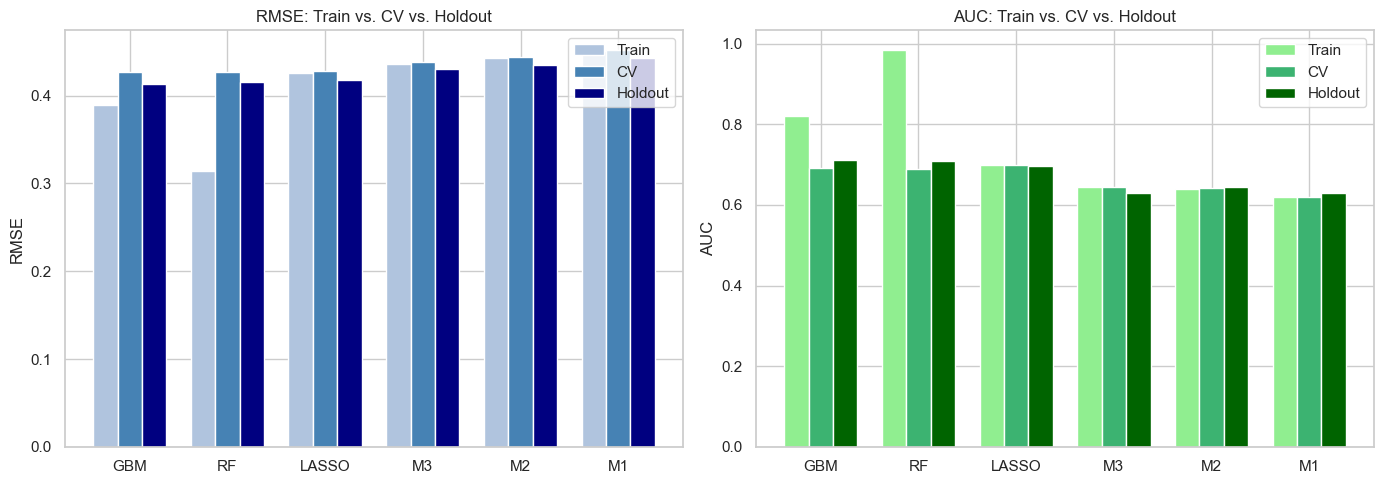

In [12]:
# horserace visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = summary["Model"].values
x = np.arange(len(models))
width = 0.25

# RMSE panel
axes[0].bar(x - width, summary["Train RMSE"], width, label="Train", color="lightsteelblue")
axes[0].bar(x, summary["CV RMSE"], width, label="CV", color="steelblue")
axes[0].bar(x + width, summary["Holdout RMSE"], width, label="Holdout", color="navy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE: Train vs. CV vs. Holdout")
axes[0].legend()

# AUC panel
axes[1].bar(x - width, summary["Train AUC"], width, label="Train", color="lightgreen")
axes[1].bar(x, summary["CV AUC"], width, label="CV", color="mediumseagreen")
axes[1].bar(x + width, summary["Holdout AUC"], width, label="Holdout", color="darkgreen")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel("AUC")
axes[1].set_title("AUC: Train vs. CV vs. Holdout")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/horserace.png", dpi=150, bbox_inches="tight")
plt.show()

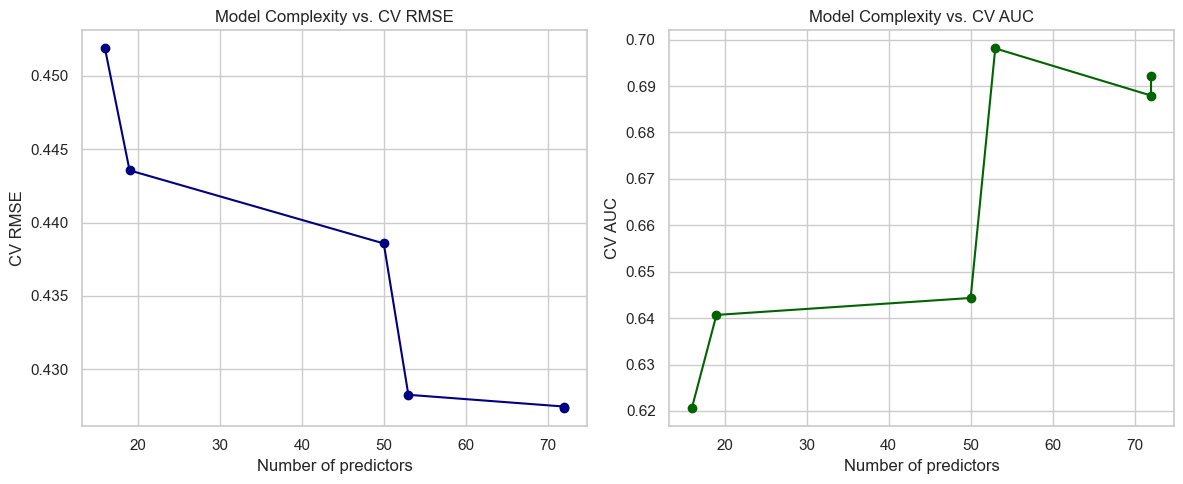

In [13]:
# model complexity vs performance plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(summary["N vars"], summary["CV RMSE"], 
             marker="o", color="navy")
axes[0].set_xlabel("Number of predictors")
axes[0].set_ylabel("CV RMSE")
axes[0].set_title("Model Complexity vs. CV RMSE")

axes[1].plot(summary["N vars"], summary["CV AUC"], 
             marker="o", color="darkgreen")
axes[1].set_xlabel("Number of predictors")
axes[1].set_ylabel("CV AUC")
axes[1].set_title("Model Complexity vs. CV AUC")

plt.tight_layout()
plt.savefig("../outputs/model_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1 - Probability prediction / Classification / Discussion of results

Business context: Let's assume we are an investment fund screening firms for growth-stage financing. Missing a fast-growth firm (false negative - FN ) means lost returns; false alarms (fale positives - FP) waste due diligence resources.
FN is costlier because the upside of a fast-growth investment far exceeds the cost of evaluating a non-grower.

In [14]:
# helper functions


def sigmoid_array(x):
    return 1 / (1 + np.exp(-x))

def generate_fold_prediction(model, X, fold, param_index):
    """Extract per-fold coefficients and predict — proper out-of-fold prediction."""
    fold_coef = model.coefs_paths_[1][fold, param_index, :]
    return sigmoid_array(
        np.dot(X, np.transpose(fold_coef)[:-1]) + np.transpose(fold_coef)[-1]
    )

def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    all_coords_copy = all_coords.copy()
    all_coords_copy["loss"] = (
        all_coords_copy.false_pos * FP + all_coords_copy.false_neg * FN
    ) / all_coords_copy.n

    t = optimal_threshold
    l = curr_exp_loss

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(all_coords_copy["thresholds"], all_coords_copy["loss"], 
            color="navy", linewidth=1.5)
    ax.axvline(x=t, linestyle="--", color="coral")
    ax.text(t + 0.02, l, f"loss = {round(l, 3)}", fontsize=10)
    ax.text(t - 0.03, all_coords_copy["loss"].max() * 0.85,
            f"threshold = {round(t, 3)}", color="coral", rotation=90, fontsize=9)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Expected Loss")
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

def create_roc_plot_with_optimal(all_coords, optimal_threshold):
    all_coords_copy = all_coords.copy()
    all_coords_copy["sp"] = 1 - all_coords_copy.true_neg / all_coords_copy.neg
    all_coords_copy["se"] = all_coords_copy.true_pos / all_coords_copy.pos

    best_coords = all_coords_copy[all_coords_copy.thresholds == optimal_threshold]
    sp = best_coords.sp.values[0]
    se = best_coords.se.values[0]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(all_coords_copy["sp"], all_coords_copy["se"], color="navy", linewidth=1.5)
    ax.fill_between(all_coords_copy["sp"], all_coords_copy["se"], 
                    alpha=0.2, color="steelblue")
    ax.scatter(sp, se, color="coral", s=100, zorder=5)
    ax.text(sp, se + 0.03, f"({round(sp, 2)}, {round(se, 2)})", 
            fontsize=10, ha="center")
    ax.plot([0, 1], [0, 1], linestyle=":", color="gray")
    ax.set_xlabel("False Positive Rate (1-Specificity)")
    ax.set_ylabel("True Positive Rate (Sensitivity)")
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

In [15]:
# loss function setup
FP = 1
FN = 5
cost = FN / FP
prevalence = y_train.sum() / len(y_train)

print(f"FP = {FP}, FN = {FN}, cost ratio = {cost}")
print(f"Prevalence = {prevalence:.3f}")

FP = 1, FN = 5, cost ratio = 5.0
Prevalence = 0.291


In [16]:

# logit models - find optimal thresholds — logit models (ch17 pattern)

best_thresholds_cv = {}
expected_loss_cv = {}
fold5_threshold = {}
fold5_expected_loss = {}
fold5_all_coords = {}

# map model names to X matrices and c_index
logit_X_map = {
    "M1": (data_train[logit_1_vars], 0),
    "M2": (data_train[logit_2_vars], 0),
    "M3": (data_train[logit_3_vars], 0),
}

# add LASSO with its best lambda index
lasso_scores = logit_models["LASSO"].scores_[1]
best_lambda_i = np.argmax(lasso_scores.mean(axis=0))
logit_X_map["LASSO"] = (
    pd.DataFrame(
        scaler.transform(data_train[logit_4_vars]),
        columns=logit_4_vars, index=data_train.index
    ),
    best_lambda_i
)

for model_name, (X, c_index) in logit_X_map.items():
    best_thresholds = []
    expected_loss = []
    
    fold = 0
    for train_index, test_index in k.split(X):
        X_fold = X.iloc[test_index, :]
        y_fold = y_train.iloc[test_index]
        
        # proper out-of-fold prediction using fold-specific coefficients
        pred_fold = generate_fold_prediction(
            logit_models[model_name], X_fold, fold, c_index
        )
        
        fpr, tpr, thresholds = roc_curve(y_fold, pred_fold)
        
        # Optimal threshold (from ch17 formula)
        optimal_threshold = sorted(
            list(zip(
                np.abs(tpr + (1 - prevalence) / (cost * prevalence) * (1 - fpr)),
                thresholds
            )),
            key=lambda i: i[0],
            reverse=True,
        )[0][1]
        
        best_thresholds.append(optimal_threshold)
        
        threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
        tn, fp, fn, tp = confusion_matrix(
            y_fold, threshold_prediction, labels=[0, 1]
        ).ravel()
        curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
        expected_loss.append(curr_exp_loss)
        fold += 1
    
    best_thresholds_cv[model_name] = np.mean(best_thresholds)
    expected_loss_cv[model_name] = np.mean(expected_loss)
    
    # save fold 5 for plotting
    fold5_threshold[model_name] = optimal_threshold
    fold5_expected_loss[model_name] = curr_exp_loss
    fold5_all_coords[model_name] = pd.DataFrame({
        "false_pos": fpr * sum(y_fold == 0),
        "true_pos": tpr * sum(y_fold == 1),
        "false_neg": sum(y_fold == 1) - tpr * sum(y_fold == 1),
        "true_neg": sum(y_fold == 0) - fpr * sum(y_fold == 0),
        "pos": sum(y_fold == 1),
        "neg": sum(y_fold == 0),
        "n": len(y_fold),
        "thresholds": thresholds,
    })
    
    print(f"{model_name:>5s}: avg threshold = {best_thresholds_cv[model_name]:.3f}, "
          f"avg expected loss = {expected_loss_cv[model_name]:.4f}")

   M1: avg threshold = 0.220, avg expected loss = 0.6955
   M2: avg threshold = 0.212, avg expected loss = 0.6946
   M3: avg threshold = 0.160, avg expected loss = 0.6955
LASSO: avg threshold = 0.157, avg expected loss = 0.6665


In [17]:

# Random Forest - find optimal threshold

# RF must be refit on each fold (no coefs_paths_ available)
X_rf_train = data_train[logit_4_vars]
best_rf_params = rf_grid.best_params_

best_thresholds_rf = []
expected_loss_rf = []

fold = 0
for train_index, test_index in k.split(X_rf_train):
    X_fold = X_rf_train.iloc[test_index, :]
    y_fold = y_train.iloc[test_index]
    X_fold_train = X_rf_train.iloc[train_index, :]
    y_fold_train = y_train.iloc[train_index]
    
    # refit RF with best params on this fold's training data
    rf_fold = RandomForestClassifier(
        random_state=random_seed,
        n_estimators=500,
        oob_score=True,
        criterion="gini",
        max_features=best_rf_params["max_features"],
        min_samples_split=best_rf_params["min_samples_split"],
    )
    rf_fold.fit(X_fold_train, y_fold_train)
    pred_fold = rf_fold.predict_proba(X_fold)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_fold, pred_fold)
    
    optimal_threshold = sorted(
        list(zip(
            np.abs(tpr + (1 - prevalence) / (cost * prevalence) * (1 - fpr)),
            thresholds
        )),
        key=lambda x: x[0],
        reverse=True,
    )[0][1]
    
    best_thresholds_rf.append(optimal_threshold)
    threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(
        y_fold, threshold_prediction, labels=[0, 1]
    ).ravel()
    curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
    expected_loss_rf.append(curr_exp_loss)
    fold += 1

best_thresholds_cv["RF"] = np.mean(best_thresholds_rf)
expected_loss_cv["RF"] = np.mean(expected_loss_rf)

# save fold 5 for plotting
fold5_threshold["RF"] = optimal_threshold
fold5_expected_loss["RF"] = curr_exp_loss
fold5_all_coords["RF"] = pd.DataFrame({
    "false_pos": fpr * sum(y_fold == 0),
    "true_pos": tpr * sum(y_fold == 1),
    "false_neg": sum(y_fold == 1) - tpr * sum(y_fold == 1),
    "true_neg": sum(y_fold == 0) - fpr * sum(y_fold == 0),
    "pos": sum(y_fold == 1),
    "neg": sum(y_fold == 0),
    "n": len(y_fold),
    "thresholds": thresholds,
})

print(f"   RF: avg threshold = {best_thresholds_cv['RF']:.3f}, "
      f"avg expected loss = {expected_loss_cv['RF']:.4f}")

   RF: avg threshold = 0.160, avg expected loss = 0.6644


In [18]:

# GBM - find optimal threshold refit per fold like RF

X_gbm_train = data_train[logit_4_vars]
best_gbm_params = gbm_search.best_params_

best_thresholds_gbm = []
expected_loss_gbm = []

fold = 0
for train_index, test_index in k.split(X_gbm_train):
    X_fold = X_gbm_train.iloc[test_index, :]
    y_fold = y_train.iloc[test_index]
    X_fold_train = X_gbm_train.iloc[train_index, :]
    y_fold_train = y_train.iloc[train_index]
    
    gbm_fold = GradientBoostingClassifier(
        random_state=random_seed,
        n_estimators=500,
        max_depth=best_gbm_params["max_depth"],
        learning_rate=best_gbm_params["learning_rate"],
        min_samples_split=best_gbm_params["min_samples_split"],
    )
    gbm_fold.fit(X_fold_train, y_fold_train)
    pred_fold = gbm_fold.predict_proba(X_fold)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_fold, pred_fold)
    
    optimal_threshold = sorted(
        list(zip(
            np.abs(tpr + (1 - prevalence) / (cost * prevalence) * (1 - fpr)),
            thresholds
        )),
        key=lambda x: x[0],
        reverse=True,
    )[0][1]
    
    best_thresholds_gbm.append(optimal_threshold)
    threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(
        y_fold, threshold_prediction, labels=[0, 1]
    ).ravel()
    curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
    expected_loss_gbm.append(curr_exp_loss)
    fold += 1

best_thresholds_cv["GBM"] = np.mean(best_thresholds_gbm)
expected_loss_cv["GBM"] = np.mean(expected_loss_gbm)

fold5_threshold["GBM"] = optimal_threshold
fold5_expected_loss["GBM"] = curr_exp_loss
fold5_all_coords["GBM"] = pd.DataFrame({
    "false_pos": fpr * sum(y_fold == 0),
    "true_pos": tpr * sum(y_fold == 1),
    "false_neg": sum(y_fold == 1) - tpr * sum(y_fold == 1),
    "true_neg": sum(y_fold == 0) - fpr * sum(y_fold == 0),
    "pos": sum(y_fold == 1),
    "neg": sum(y_fold == 0),
    "n": len(y_fold),
    "thresholds": thresholds,
})

print(f"  GBM: avg threshold = {best_thresholds_cv['GBM']:.3f}, "
      f"avg expected loss = {expected_loss_cv['GBM']:.4f}")

  GBM: avg threshold = 0.155, avg expected loss = 0.6636


In [19]:

# classification summary table
summary["CV threshold"] = summary["Model"].map(best_thresholds_cv)
summary["CV expected loss"] = summary["Model"].map(expected_loss_cv)

(summary.set_index("Model").style
    .format({
        "N vars": "{:d}",
        "Train RMSE": "{:.4f}", "CV RMSE": "{:.4f}", "Holdout RMSE": "{:.4f}",
        "Train AUC": "{:.4f}", "CV AUC": "{:.4f}", "Holdout AUC": "{:.4f}",
        "CV threshold": "{:.3f}",
        "CV expected loss": "{:.4f}",
    })
    .set_caption(f"Model Summary with Loss Function (FP={FP}, FN={FN})")
    .background_gradient(subset=["CV RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["CV AUC", "Holdout AUC"], cmap="RdYlGn")
    .background_gradient(subset=["CV expected loss"], cmap="RdYlGn_r")
)

,N vars,Train RMSE,CV RMSE,Holdout RMSE,Train AUC,CV AUC,Holdout AUC,CV threshold,CV expected loss
Model,,,,,,,,,
GBM,72,0.3893,0.4273,0.4138,0.8211,0.6922,0.7117,0.155,0.6636
RF,72,0.3146,0.4275,0.4158,0.9838,0.6879,0.7098,0.160,0.6644
LASSO,53,0.4257,0.4283,0.4184,0.6980,0.6981,0.6973,0.157,0.6665
M3,50,0.4362,0.4386,0.4307,0.6440,0.6443,0.6305,0.160,0.6955
M2,19,0.4425,0.4436,0.4350,0.6405,0.6407,0.6447,0.212,0.6946
M1,16,0.4509,0.4519,0.4424,0.6204,0.6206,0.6293,0.220,0.6955


Best model by expected loss: GBM


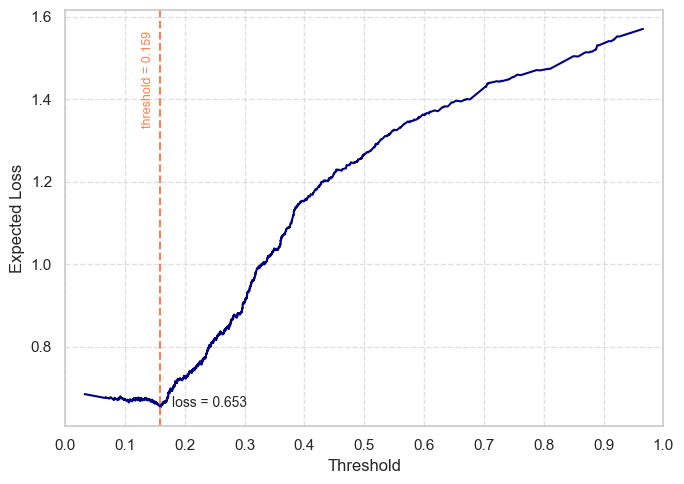

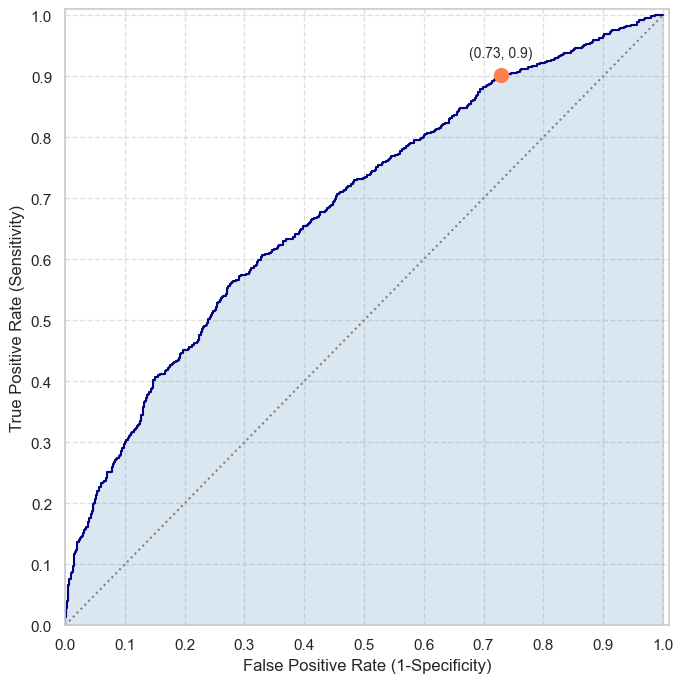

In [20]:

# loss and ROC plots (fold 5, best model)

best_model_name = summary.sort_values("CV expected loss").iloc[0]["Model"]
print(f"Best model by expected loss: {best_model_name}")

create_loss_plot(
    fold5_all_coords[best_model_name],
    fold5_threshold[best_model_name],
    fold5_expected_loss[best_model_name]
)

create_roc_plot_with_optimal(
    fold5_all_coords[best_model_name],
    fold5_threshold[best_model_name]
)

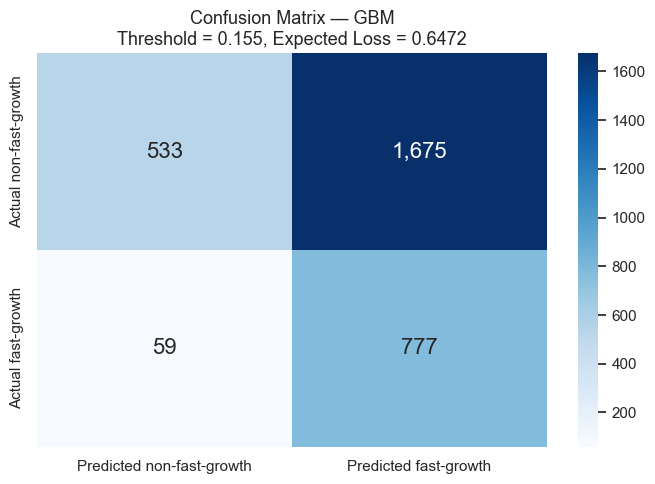

Precision: 0.317
Recall:    0.929
Accuracy:  0.430


In [21]:

# holdout evaluation — best model

best_model = logit_models[best_model_name]
best_threshold = best_thresholds_cv[best_model_name]

# Get holdout predictions
if best_model_name in ["M1", "M2", "M3"]:
    var_map = {"M1": logit_1_vars, "M2": logit_2_vars, "M3": logit_3_vars}
    X_ho = data_holdout[var_map[best_model_name]]
elif best_model_name == "LASSO":
    X_ho = pd.DataFrame(
        scaler.transform(data_holdout[logit_4_vars]),
        columns=logit_4_vars, index=data_holdout.index
    )
elif best_model_name == "RF":
    X_ho = data_holdout[logit_4_vars]
elif best_model_name == "GBM":
    X_ho = data_holdout[logit_4_vars]

pred_holdout = best_model.predict_proba(X_ho)[:, 1]
holdout_prediction = np.where(pred_holdout < best_threshold, 0, 1)

# confusion matrix
cm = confusion_matrix(y_holdout, holdout_prediction, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
expected_loss_holdout = (fp * FP + fn * FN) / len(y_holdout)
cm_df = pd.DataFrame(
    cm,
    index=["Actual non-fast-growth", "Actual fast-growth"],
    columns=["Predicted non-fast-growth", "Predicted fast-growth"],
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues",
            annot_kws={"size": 16}, ax=ax)
ax.set_title(f"Confusion Matrix — {best_model_name}\n"
             f"Threshold = {best_threshold:.3f}, "
             f"Expected Loss = {expected_loss_holdout:.4f}", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Precision: {cm[1,1] / (cm[1,1] + cm[0,1]):.3f}")
print(f"Recall:    {cm[1,1] / (cm[1,1] + cm[1,0]):.3f}")
print(f"Accuracy:  {(cm[0,0] + cm[1,1]) / cm.sum():.3f}")

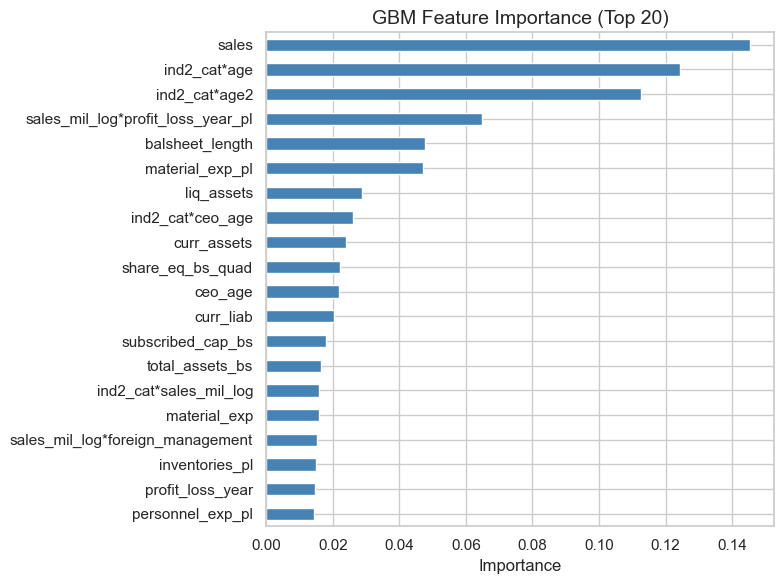

In [22]:
# feature importance for GBM - Top 20
importances = pd.Series(
    best_gbm.feature_importances_, index=logit_4_vars
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("GBM Feature Importance (Top 20)", fontsize=14)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Discussion of Results

Our best model is Gradient Boosting (GBM), which achieves the lowest CV expected loss (0.664) and the highest holdout AUC (0.712). Unlike Random Forest, which severely overfits (Train AUC 0.98 vs CV 0.69), GBM shows a healthier gap (Train 0.82 vs CV 0.69) and actually improves on holdout (AUC 0.712). This confirms that CV performance generalizes well.

**Classification trade-offs.** With FN costing 5× FP, the optimal threshold drops to 0.16. This is below the 29% base rate for fast_growth. This produces high recall (93%) but low precision (32%). We are able to catch almost every fast-growth firm at the cost of many false alarms. This is rational when missing a high-growth opportunity is far costlier than time wasted in due diligence.

**Practical usefulness.** The model works as a screening tool. The model works as a screening tool. From approximately 3,000 firms it eliminates about 500 unlikely growers while missing only 59 true fast-growth firms. Operationally, a second stage of manual due diligence would then filter the 1,675 false positives.

**Model comparison.** GBM edges out RF on expected loss and generalizes better. LASSO offers nearly identical CV performance with perfect stability (Train/CV AUC both 0.70) and interpretable coefficients — in production where transparency matters, LASSO remains a strong alternative.

**Limitations.** AUC of 0.71 reflects moderate discriminatory power. Firm growth depends heavily on unobserved factors (market opportunities, innovation, management quality) that financial statements cannot capture.

**Key predictors.** Feature importance confirms that sales level dominates, followed by industry-age interactions and the sales-profitability interaction — consistent with corporate finance intuition that growth is driven by scale, firm maturity, and the ability to convert revenue into profit.

## Task 2 - Industry Categories

In [23]:

# industry Comparison
# Split into manufacturing (NACE 10-33) and services (55-56)

data_manuf = data[data["manufacturing_flg"] == 1].copy()
data_serv = data[data["services_flg"] == 1].copy()

print(f"Manufacturing: {len(data_manuf):,} firms, "
      f"fast-growth rate: {data_manuf['fast_growth'].mean():.1%}")
print(f"Services:      {len(data_serv):,} firms, "
      f"fast-growth rate: {data_serv['fast_growth'].mean():.1%}")

Manufacturing: 4,992 firms, fast-growth rate: 29.0%
Services:      10,228 firms, fast-growth rate: 28.7%


In [24]:
# run full pipeline for both industries using best GBM model and parameters from overall training
best_gbm_params = gbm_search.best_params_
industry_results = {}

for label, data_ind in [("Manufacturing", data_manuf), ("Services", data_serv)]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    
    # Train/holdout split
    d_train, d_holdout = train_test_split(
        data_ind, test_size=0.2, random_state=random_seed
    )
    y_tr = d_train["fast_growth"].astype(int)
    y_ho = d_holdout["fast_growth"].astype(int)
    
    X_tr = d_train[logit_4_vars]
    X_ho = d_holdout[logit_4_vars]
    
    # Fit GBM with grid search
    gbm_ind = GradientBoostingClassifier(
        n_estimators=500, random_state=random_seed
    )
    gbm_grid_ind = GridSearchCV(
        gbm_ind, gbm_grid, cv=k, refit="roc_auc",
        scoring=["roc_auc", "neg_brier_score"],
        n_jobs=-1
    )
    gbm_grid_ind.fit(X_tr, y_tr)
    best_gbm_ind = gbm_grid_ind.best_estimator_
    
    print(f"  Best params: {gbm_grid_ind.best_params_}")
    
    # CV RMSE and AUC from grid search
    gbm_res = pd.DataFrame(gbm_grid_ind.cv_results_)
    best_idx = gbm_grid_ind.best_index_
    cv_rmse = np.sqrt(-gbm_res.loc[best_idx, "mean_test_neg_brier_score"])
    cv_auc = gbm_res.loc[best_idx, "mean_test_roc_auc"]
    
    # Optimal threshold via loss function (refit per fold)
    prevalence_ind = y_tr.mean()
    best_thresholds = []
    expected_losses = []
    
    fold = 0
    for train_idx, val_idx in k.split(X_tr):
        X_fold_train = X_tr.iloc[train_idx]
        y_fold_train = y_tr.iloc[train_idx]
        X_fold_val = X_tr.iloc[val_idx]
        y_fold_val = y_tr.iloc[val_idx]
        
        gbm_fold = GradientBoostingClassifier(
            n_estimators=500,
            random_state=random_seed,
            **gbm_grid_ind.best_params_
        )
        gbm_fold.fit(X_fold_train, y_fold_train)
        pred_fold = gbm_fold.predict_proba(X_fold_val)[:, 1]
        
        fpr, tpr, thresholds = roc_curve(y_fold_val, pred_fold)
        optimal_t = sorted(
            list(zip(
                np.abs(tpr + (1 - prevalence_ind) / (cost * prevalence_ind) * (1 - fpr)),
                thresholds
            )),
            key=lambda i: i[0], reverse=True,
        )[0][1]
        
        best_thresholds.append(optimal_t)
        y_pred = np.where(pred_fold < optimal_t, 0, 1)
        tn, fp, fn, tp = confusion_matrix(y_fold_val, y_pred, labels=[0, 1]).ravel()
        expected_losses.append((fp * FP + fn * FN) / len(y_fold_val))
        fold += 1
    
    avg_threshold = np.mean(best_thresholds)
    avg_loss = np.mean(expected_losses)
    
    # Holdout evaluation
    pred_ho = best_gbm_ind.predict_proba(X_ho)[:, 1]
    ho_pred = np.where(pred_ho < avg_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(y_ho, ho_pred, labels=[0, 1]).ravel()
    ho_loss = (fp * FP + fn * FN) / len(y_ho)
    ho_rmse = np.sqrt(mean_squared_error(y_ho, pred_ho))
    ho_auc = roc_auc_score(y_ho, pred_ho)
    
    industry_results[label] = {
        "N firms": len(data_ind),
        "Fast-growth rate": f"{data_ind['fast_growth'].mean():.1%}",
        "CV RMSE": cv_rmse,
        "CV AUC": cv_auc,
        "CV threshold": avg_threshold,
        "CV expected loss": avg_loss,
        "Holdout RMSE": ho_rmse,
        "Holdout AUC": ho_auc,
        "Holdout expected loss": ho_loss,
        "Holdout TP": tp,
        "Holdout FP": fp,
        "Holdout FN": fn,
        "Holdout TN": tn,
    }
    
    print(f"  N = {len(data_ind):,}, fast-growth = {data_ind['fast_growth'].mean():.1%}")
    print(f"  CV RMSE: {cv_rmse:.4f}, CV AUC: {cv_auc:.4f}")
    print(f"  Threshold: {avg_threshold:.3f}, CV loss: {avg_loss:.4f}")
    print(f"  Holdout RMSE: {ho_rmse:.4f}, AUC: {ho_auc:.4f}, loss: {ho_loss:.4f}")


  Manufacturing
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 16}
  N = 4,992, fast-growth = 29.0%
  CV RMSE: 0.4487, CV AUC: 0.6193
  Threshold: 0.103, CV loss: 0.6965
  Holdout RMSE: 0.4460, AUC: 0.6348, loss: 0.6807

  Services
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 16}
  N = 10,228, fast-growth = 28.7%
  CV RMSE: 0.4179, CV AUC: 0.7218
  Threshold: 0.144, CV loss: 0.6283
  Holdout RMSE: 0.4227, AUC: 0.7084, loss: 0.6285


In [25]:
# comparison table
comp = pd.DataFrame(industry_results).T
comp_display = comp[["N firms", "Fast-growth rate",
                      "CV RMSE", "CV AUC", "CV threshold", 
                      "CV expected loss", "Holdout AUC", "Holdout expected loss"]]

(comp_display.style
    .format({
        "N firms": "{:,}",
        "CV RMSE": "{:.4f}", "CV AUC": "{:.4f}",
        "CV threshold": "{:.3f}",
        "CV expected loss": "{:.4f}",
        "Holdout AUC": "{:.4f}",
        "Holdout expected loss": "{:.4f}",
    })
    .set_caption("Task 2: Industry Comparison (GBM, FP=1, FN=5)")
    .background_gradient(subset=["CV RMSE", "CV expected loss", "Holdout expected loss"], cmap="RdYlGn_r")
    .background_gradient(subset=["CV AUC", "Holdout AUC"], cmap="RdYlGn")
)

,N firms,Fast-growth rate,CV RMSE,CV AUC,CV threshold,CV expected loss,Holdout AUC,Holdout expected loss
Manufacturing,"4,992",29.0%,0.4487,0.6193,0.103,0.6965,0.6348,0.6807
Services,"10,228",28.7%,0.4179,0.7218,0.144,0.6283,0.7084,0.6285


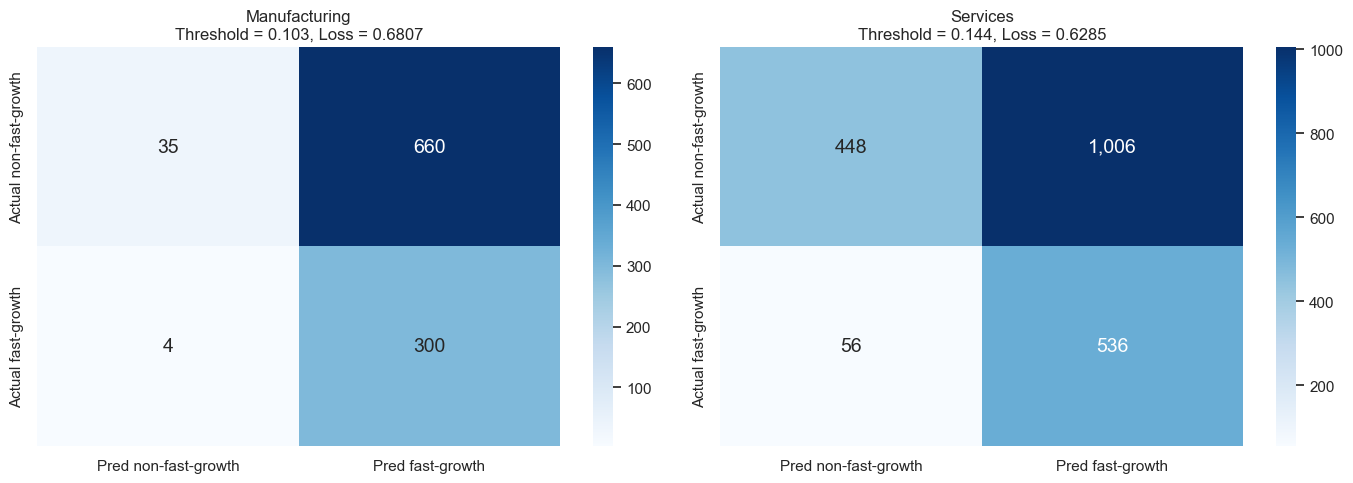

In [26]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label in zip(axes, ["Manufacturing", "Services"]):
    r = industry_results[label]
    cm = np.array([[r["Holdout TN"], r["Holdout FP"]], 
                   [r["Holdout FN"], r["Holdout TP"]]])
    cm_df = pd.DataFrame(
        cm,
        index=["Actual non-fast-growth", "Actual fast-growth"],
        columns=["Pred non-fast-growth", "Pred fast-growth"],
    )
    sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues",
                annot_kws={"size": 14}, ax=ax)
    ax.set_title(f"{label}\nThreshold = {r['CV threshold']:.3f}, "
                 f"Loss = {r['Holdout expected loss']:.4f}", fontsize=12)

plt.tight_layout()
plt.savefig("../outputs/confusion_industry.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 2: Industry Comparison

The selected GBM model performs notably better on services (CV AUC 0.72, holdout loss 0.63) than manufacturing (CV AUC 0.62, holdout loss 0.68). First off, the services sample is twice as large, but the gap likely also reflects that services firms (accommodation, food) operate in more standardized markets where financial ratios are more predictive.

The threshold for manufacturing (0.103) is so aggressive it screens out only 35 of 999 holdout firms. The model adds little discriminatory value. Services retains meaningful screening, eliminating ~450 firms while missing only 56 fast-growers. In practice, this model is a useful first filter for services but would need sector-specific features 
(export intensity, capital expenditure) to be effective for manufacturing.